In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("arunrk7/surface-crack-detection")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
Path to dataset files: /kaggle/input/surface-crack-detection


In [20]:
import cv2
import glob
import shutil
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
os.listdir(path)

['Negative', 'Positive']

In [4]:
xdata = []
ydata = []
data = os.path.join(path, 'Negative')
print (data)

/kaggle/input/surface-crack-detection/Negative


In [5]:
output_path = "content/crack_detection_split"
train_dir = os.path.join(output_path, 'train')
test_dir = os.path.join(output_path, 'test')
val_dir = os.path.join(output_path, 'val')

In [6]:
for folder in [train_dir, test_dir, val_dir]:
    for subfolder in ['Positive', 'Negative']:
        os.makedirs(os.path.join(folder, subfolder), exist_ok=True)

In [7]:
count_positive = 0
count_negative = 0
def spliting (data, train_size, test_size, valsize = 0.0):
  data_size = len(data)
  random.shuffle(data)
  train_data_size = int(data_size * train_size)
  test_data_size = int(data_size * test_size)
  val_data_size = int(data_size * valsize)
  train_data = data[:train_data_size]
  test_data = data[train_data_size:train_data_size + test_data_size]
  val_data = data[train_data_size + test_data_size:]
  return train_data, test_data, val_data
negative = spliting (glob.glob(os.path.join(path, 'Negative')+ "/**"), 0.7,0.2,0.1)
positive = spliting (glob.glob(os.path.join(path, 'Positive')+ "/**"), 0.7,0.2,0.1)
for data_num, data in enumerate([negative, positive]):
  for state_num, state in enumerate(data): # train test valid
    for file in state:
      if data_num == 0:
        count_negative += 1
        if state_num == 0:
          shutil.copy(file, os.path.join(train_dir, 'Negative'))
        elif state_num == 1:
          shutil.copy(file, os.path.join(test_dir, 'Negative'))
        else:
          shutil.copy(file, os.path.join(val_dir, 'Negative'))
      else:
        count_positive += 1
        if state_num == 0:
          shutil.copy(file, os.path.join(train_dir, 'Positive'))
        elif state_num == 1:
          shutil.copy(file, os.path.join(test_dir, 'Positive'))
        else:
          shutil.copy(file, os.path.join(val_dir, 'Positive'))
print (f"Total number of positive images: {count_positive}")
print (f"Total number of negative images: {count_negative}")

Total number of positive images: 20000
Total number of negative images: 20000


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_images_generator = ImageDataGenerator(
    rescale=1./255)
train_generator = train_images_generator.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, color_mode = 'rgb', class_mode='binary', shuffle=True)

valid_images_generator = ImageDataGenerator(
    rescale=1./255)
validation_generator = valid_images_generator.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, color_mode = 'rgb', class_mode='binary', shuffle=True)

test_images_generator = ImageDataGenerator(
    rescale=1./255)
test_generator = test_images_generator.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, color_mode = 'rgb', class_mode='binary', shuffle=False)

Found 36364 images belonging to 2 classes.
Found 7597 images belonging to 2 classes.
Found 14370 images belonging to 2 classes.


In [10]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, AvgPool2D, Dense, Flatten, Dropout, GlobalAvgPool2D, BatchNormalization
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.applications.vgg16 import VGG16
%pip install ultralytics
from ultralytics import YOLO

In [11]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
model = Sequential([
    base_model,
    GlobalAvgPool2D(),
    BatchNormalization(),
    Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,953 (90.02 MB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [13]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                      mode='min',
                                      verbose=1,
                                      patience=3,
                                      restore_best_weights=True)

mc = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.keras",
                                        monitor='val_loss',
                                        mode='min',
                                        verbose=1,
                                        save_best_only=True)

In [14]:
history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=20, callbacks=[es, mc])

Epoch 1/20
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9442 - loss: 0.1685
Epoch 1: val_loss improved from None to 0.06919, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 169s 128ms/step - accuracy: 0.9597 - loss: 0.1223 - val_accuracy: 0.9788 - val_loss: 0.0692
Epoch 2/20
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9731 - loss: 0.0841
Epoch 2: val_loss improved from 0.06919 to 0.05372, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 122s 108ms/step - accuracy: 0.9741 - loss: 0.0797 - val_accuracy: 0.9822 - val_loss: 0.0537
Epoch 3/20
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9767 - loss: 0.0701
Epoch 3: val_loss improved from 0.05372 to 0.04778, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 122s 107ms/step - accuracy: 0.9776 - loss: 0.068

In [15]:
model.evaluate(test_generator)

450/450 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - accuracy: 0.9895 - loss: 0.0303


[0.030300505459308624, 0.9894919991493225]

Text(0.5, 0, 'epoch')

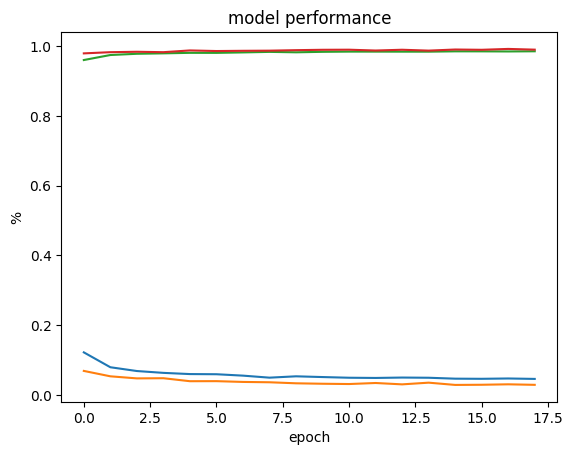

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model performance')
plt.ylabel('%')
plt.xlabel('epoch')

In [17]:
ypred = model.predict(test_generator)

450/450 ━━━━━━━━━━━━━━━━━━━━ 48s 98ms/step


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
test_generator.class_indices

{'Negative': 0, 'Positive': 1}

In [19]:
y_true = test_generator.classes
y_pred_binary = (ypred > 0.5).astype(int)

conf_matrix = confusion_matrix(y_true, y_pred_binary)
class_report = classification_report(y_true, y_pred_binary)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
[[7126   55]
 [  96 7093]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7181
           1       0.99      0.99      0.99      7189

    accuracy                           0.99     14370
   macro avg       0.99      0.99      0.99     14370
weighted avg       0.99      0.99      0.99     14370



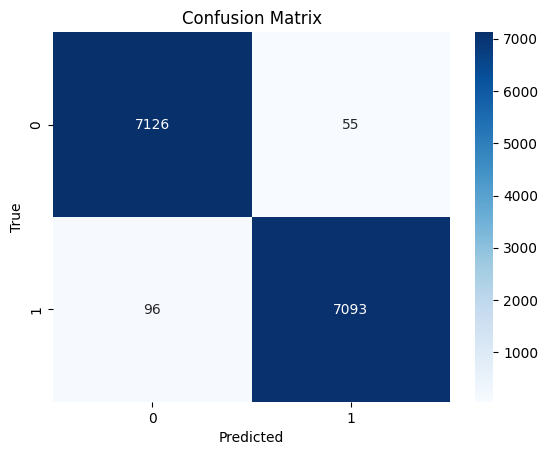

In [21]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()